# Assignment 3.1
Name:  Justin  
Date:  Nguyen

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

In [356]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

## Problem 3.2.

In an exit poll of 1648 voters in the 2020 Senatorial election in Arizona, 51.5% said they voted
for Mark Kelly and 48.5% said they voted for Martha McSally

a) Suppose that actually 50% of the population voted for Kelly. If this exit poll had the
properties of a simple random sample, find the standard error of the sample proportion
voting for him.

b) Under the 50% presumption, are the results of the exit poll surprising? Why? Would you
be willing to predict the election outcome? Explain by (i) conducting a simulation; (ii)
using the value found in (a) for the standard error.

`(a) Your answer goes here`

In [357]:
se = np.sqrt(.50 * (1 - .50) / 1648)
print(se)

0.012316615977053663


Standard Error: To calculate the standard error of ~.01, I took the square root of p(1 - p)/n where p = the supposed probability and n = the number of voters. Standard error ~.01 means that we can expect the proportion of voters that voted for Mark Kelly is approximately 50% +- 1%

`(b) Your answer goes here`

In [358]:
samples = np.array([np.random.binomial(n=1, p=0.50, size=1648).mean() for i in range(10000)])
se = samples.std()
print(samples.mean())
print(se)
print((.515 - .50) / se)

0.49997572815533975
0.01230351513139871
1.2191637787903267


Assuming that the actual population that voted for Mark Kelly is 50%, a standard error of about 1% so the observed percentage of voters that voted for Mark Kelly (51.5%) is not unusual (51.5% is 1.22 standard errors from the mean and within 2 standard errors), therefore this exit poll does not provide strong evidence that Mark Kelly's actual vote share differs from 50%.

The results for the exit polls fall within 1.22 standard errors from the assumed 50% which is not unusual. Using this we can also safely predict that the outcome would be Mark Kelly with 50% of the votes.

## Problem 3.3.

 The 49 students in a class at the University of Florida made blinded evaluations of pairs of
cola drinks. For the 49 comparisons of Coke and Pepsi, Coke was preferred 29 times. In the
population that this sample represents, is this strong evidence that a majority prefers Coke?
Use a simulation of a sampling distribution to answer.

`Your answer goes here`

0.4990224489795918
0.0711437633567162
1.2908613539799179
0.10048645411773227


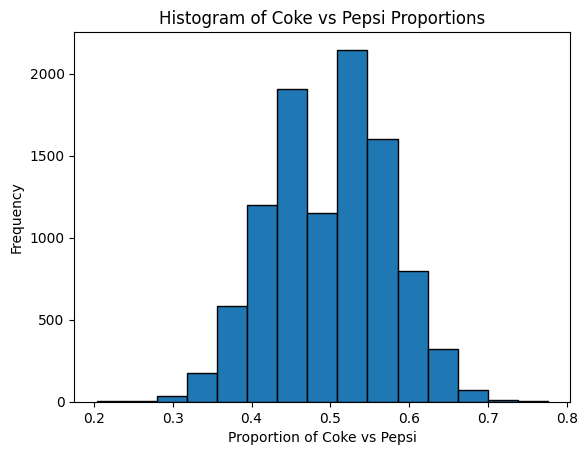

In [359]:
coke_vs_pepsi = np.array([np.random.binomial(n=1, p=0.50, size=49).mean() for i in range(10000)])
se = coke_vs_pepsi.std()
print(coke_vs_pepsi.mean())
print(se)
print(((29/49) - .50) / se)
print(1 - stats.norm.cdf(x=.59, loc=coke_vs_pepsi.mean(), scale=se))
plt.hist(coke_vs_pepsi, bins=15, edgecolor='black')
plt.xlabel('Proportion of Coke vs Pepsi')
plt.ylabel('Frequency')
plt.title('Histogram of Coke vs Pepsi Proportions')
plt.show()



Out of 49 students in a class at the University of Florida, 29 students preferred Coke over Pepsi. Running a simulation using a binomial sampling distribution with B = 10,000 repeated samples with n = 49 observations per sample, we calculate the standard error in the sampling distribution by finding it's standard deviation (~.07). Comparing the observed proportion of students who prefer Coke (~.59) to the assumed proportion ((.59 - .50) / .07), we find that the observed proportion is within 2 standard errors (~1.29) which is not unusual. The proportion of the distribution that the majority prefers Coke at or above the observed proportion (~.59) is found by calculating 1 - cdf of the right tail of the distribution (Greater or equal to the observed proportion) which is ~.11. Since only ~11% of the simulated samples could produce a result this extreme, we conclude that the observation is not strong evidence that the majority prefers Coke.

## Problem 3.5.

The example in Section 3.1.4 simulated sampling distributions of the sample mean to determine how precise $\bar{Y}$ for $n=25$ may estimate a population mean $\mu.$

a) Find the theoretical standard error of $\bar{Y}$ for the scenario values of $\sigma = 5$ and 8. How do they compare to the standard deviations of the 100,000 sample means in the simulations?

`Your answer goes here`

Replication of the simulation from example 3.1.4:

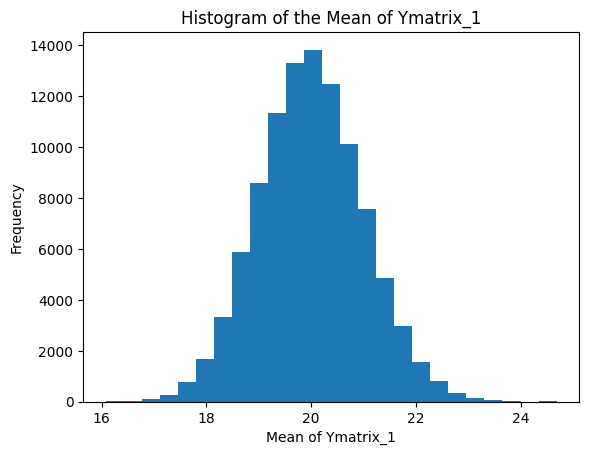

19.99896868864511
0.9967820678459659


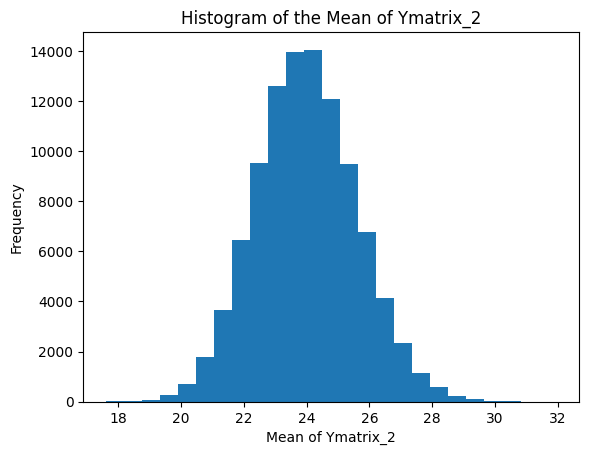

23.997705962674246
1.6011536217916613


In [360]:
Ymatrix_1 = stats.gamma.rvs(a = 16, scale = 1.25, size = 25*100000).reshape(100000, 25)
plt.hist(Ymatrix_1.mean(axis=1), bins=25)
plt.xlabel('Mean of Ymatrix_1')
plt.ylabel('Frequency')
plt.title('Histogram of the Mean of Ymatrix_1')
plt.show()
Y1_mean = Ymatrix_1.mean(axis=1).mean()
Y1_mean_std = Ymatrix_1.mean(axis=1).std()
print(Y1_mean)
print(Y1_mean_std)
Ymatrix_2 = stats.gamma.rvs(a = 9, scale = 8/3, size = 25*100000).reshape(100000, 25)
plt.hist(Ymatrix_2.mean(axis=1), bins=25)
plt.xlabel('Mean of Ymatrix_2')
plt.ylabel('Frequency')
plt.title('Histogram of the Mean of Ymatrix_2')
plt.show()
Y2_mean = Ymatrix_2.mean(axis=1).mean()
Y2_mean_std = Ymatrix_2.mean(axis=1).std()
print(Y2_mean)
print(Y2_mean_std)

Calculation of standard errors:

In [361]:
sigma = 5 
se = sigma / 5
print(se)
sigma = 8
se = sigma / 5
print(se)

1.0
1.6


The simulated standard deviations, lower bound (20, 5) = 1.0 and the upper bound (24, 8) = 1.6, are identical to our theoretical standard errors, lower bound (5/sqrt(25)) = 1.0 and the upper bound (8/sqrt(25)) = 1.6.

b) In the first scenario, we chose $\sigma = 5$ under the belief that if $\mu = 20$, about 2/3 of the sample values would fall between `$`15 and `$`25. For the gamma distribution with $(\mu, \sigma) = (20,5),$ show that the actual probability between 15 and 25 is 0.688.

`Your answer goes here`

In [362]:
lower_bound = 15
upper_bound = 25
between_15_and_25 = stats.gamma.cdf(upper_bound, a = 16, scale = 1.25) - stats.gamma.cdf(lower_bound, a = 16, scale = 1.25)
print(between_15_and_25)

0.6879025178104403


We calculate the probability that an individual customer's spending (not the sample mean) would fall between 15 and 25 in the scenario with (mu, sigma) = (20, 5) by subtracting the cdf of the lower bound (15) from the cdf of the upper bound (25) = .688.

## Problem 3.8.

Construct the sampling distribution of the sample proportion of heads, for flipping a balanced
coin (a) once; (b) twice; (c) three times; (d) four times. Describe how the shape changes
as the number of flips $n$ increases. What would happen if $n$ kept growing? Why?


`Your answer goes here`

Used Claude here to break down the problem

1    heads  p_hat  probability
0      0    0.0          0.5
1      1    1.0          0.5
2    heads  p_hat  probability
0      0    0.0         0.25
1      1    0.5         0.50
2      2    1.0         0.25
3    heads  p_hat  probability
0      0   0.00        0.125
1      1   0.33        0.375
2      2   0.67        0.375
3      3   1.00        0.125
4    heads  p_hat  probability
0      0   0.00       0.0625
1      1   0.25       0.2500
2      2   0.50       0.3750
3      3   0.75       0.2500
4      4   1.00       0.0625
100      heads  p_hat   probability
0        0   0.00  7.888609e-31
1        1   0.01  7.888609e-29
2        2   0.02  3.904861e-27
3        3   0.03  1.275588e-25
4        4   0.04  3.093301e-24
..     ...    ...           ...
96      96   0.96  3.093301e-24
97      97   0.97  1.275588e-25
98      98   0.98  3.904861e-27
99      99   0.99  7.888609e-29
100    100   1.00  7.888609e-31

[101 rows x 3 columns]


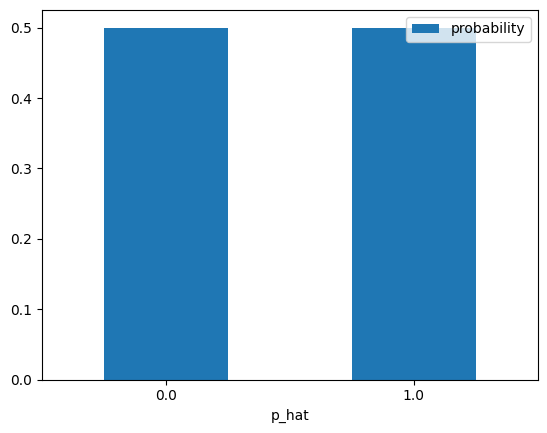

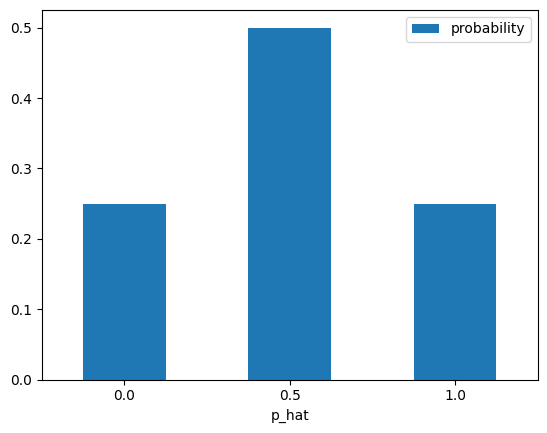

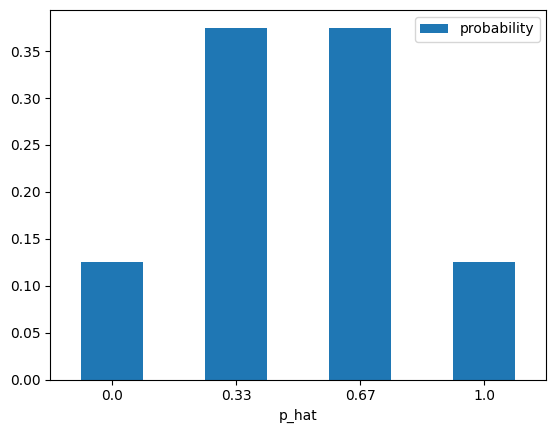

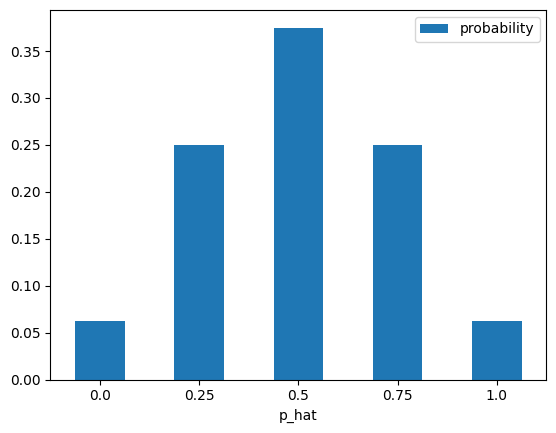

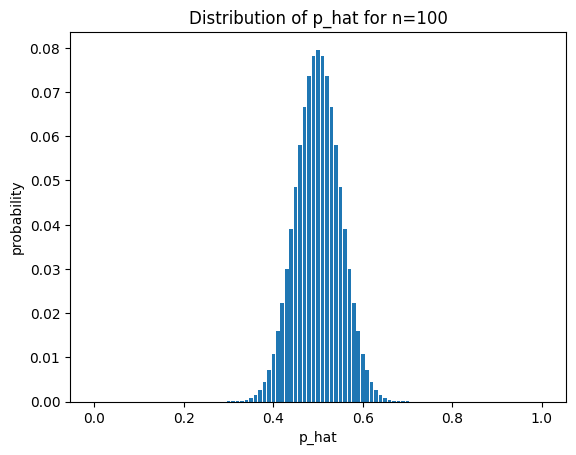

In [363]:
def p_hat_distribution(n, p=0.50):
    k = np.arange(n + 1)
    prob = stats.binom.pmf(k, n, p)
    return pd.DataFrame({
    "heads": k,
    "p_hat": k / n,
    "probability": prob
})

for n in range(1, 5):
    table = p_hat_distribution(n)
    table["p_hat"] = table["p_hat"].round(2)
    assert np.isclose(table.probability.sum(), 1)
    print(n, table)
    table.plot.bar(x="p_hat", y="probability", rot=0)

table = p_hat_distribution(100)
assert np.isclose(table.probability.sum(), 1)
print(100, table)

plt.figure()
plt.bar(table["p_hat"], table["probability"], width=0.008)
plt.xlabel("p_hat")
plt.ylabel("probability")
plt.title(f"Distribution of p_hat for n=100")
plt.show()

Claude helped with the code to plot the 100 coin flips since the template made the x label unreadable with 100 coin flips

Shape: As the number of coin flips (n) grows, the shape of the sampling distribution becomes more bell-shaped and continued growth of n would lead to a smoother curve. 

Center: The center of all four histograms are centered around .5 and does not shift as n changes. 

Supports: The number of supports grows linearly as n grows since the number of support points = n + 1.

Concentration: As n increases, the distribution concentrates more tightly around .5 with the probability of extremes (0 or 1) becoming less likely.

Symmetry: All four histograms are symmetrical around .5.

Normal approximation: For large-n, the sampling distribution of p_hat starts to look like a smooth bell-shaped curve, however, each individual flip still has only two possible outcomes (heads or tails).

## Problem 3.13.

Simulate random sampling from a uniform population distribution with several $n$ values to
illustrate the Central Limit Theorem.

`Your answer goes here`

1 5.081891022033809 2.8646788198765183
2 5.012859310297912 1.9954356015447419
5 5.006476270024858 1.3193831337058166
10 4.98956726106871 0.9185809683498851


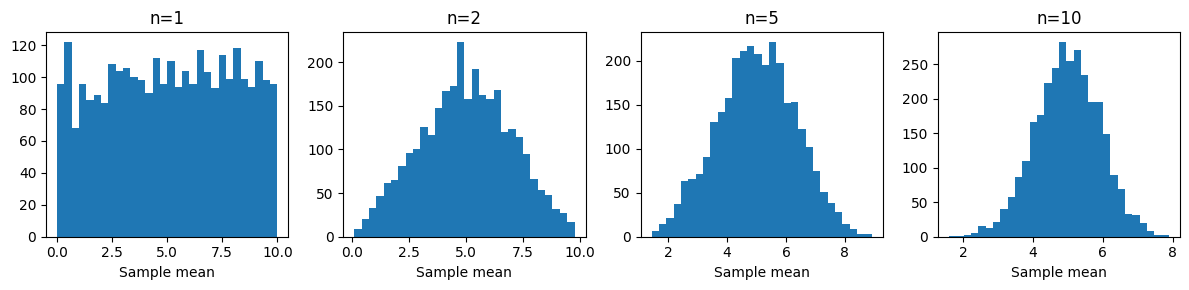

In [364]:
low, high = 0, 10
B = 3000
n_values = [1, 2, 5, 10]
fig, axes = plt.subplots(1, len(n_values), figsize=(12, 3))
for ax, n in zip(axes, n_values):
    x = np.random.uniform(low, high, size=(B, n))
    means = x.mean(axis=1)
    ax.hist(means, bins=30)
    ax.set_title(f"n={n}")
    ax.set_xlabel("Sample mean")
    print(n, means.mean(), means.std(ddof=1))
plt.tight_layout()

In this problem we make n (n = 1, 2, 5, 10) draws from a continuous range (0 through 10) and simulate B (3000) samples. Then we take each sample mean and plot it on a histogram.

n = 1: When n = 1, the distribution of the sample mean is a uniform distribution, centered around 5, and is evenly spread throughout the distribution.

n = 2: When n = 2, the distribution starts to take a triangular shape, still centered around 5, and is symmetrical on both sides of the center.

n = 5: When n = 5, the distribution is now a bell-shaped curve, still centered around 5, and is symmetrical on both sides of the center. We can also start to see an increase in concentration around the center while the extremes are becoming more rare.

n = 10: Same as the distribution when n = 5 but now the bell-shaped curve is more concentrated around the center.

## Problem 3.14.

On each bet in a sequence of bets, you win 1 dollar with probability 0.50 and lose 1 dollar (i.e., win negative 1 dollar) with probability 0.50. Let $Y$ denote the total of your winnings and losings after 100 bets. Giving your reasoning, state the approximate distribution of $Y.$ 

`Your answer goes here`

   wins  losses  winnings  probability        Y_mean  Y_var  Y_std
0     0       1        -1          0.5 -1.110223e-16    1.0    1.0
1     1       0         1          0.5 -1.110223e-16    1.0    1.0
     wins  losses  winnings   probability        Y_mean  Y_var  Y_std
0       0     100      -100  7.888609e-31 -1.823194e-15  100.0   10.0
1       1      99       -98  7.888609e-29 -1.823194e-15  100.0   10.0
2       2      98       -96  3.904861e-27 -1.823194e-15  100.0   10.0
3       3      97       -94  1.275588e-25 -1.823194e-15  100.0   10.0
4       4      96       -92  3.093301e-24 -1.823194e-15  100.0   10.0
..    ...     ...       ...           ...           ...    ...    ...
96     96       4        92  3.093301e-24 -1.823194e-15  100.0   10.0
97     97       3        94  1.275588e-25 -1.823194e-15  100.0   10.0
98     98       2        96  3.904861e-27 -1.823194e-15  100.0   10.0
99     99       1        98  7.888609e-29 -1.823194e-15  100.0   10.0
100   100       0       100  

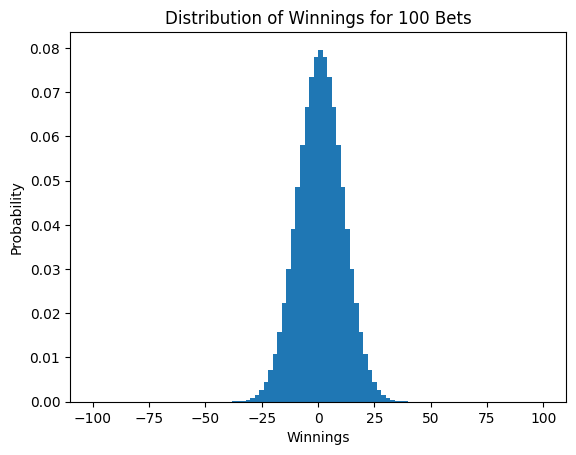

In [365]:
def bets(n):
    k = np.arange(n + 1)
    prob = stats.binom.pmf(k, n, 0.5)
    winnings = k - (n - k)
    Y_mean = np.sum(winnings * prob)
    Y_var = np.sum((winnings - Y_mean)**2 * prob)
    Y_std = np.sqrt(Y_var)
    return pd.DataFrame({"wins": k, "losses": n - k, "winnings": winnings, "probability": prob, "Y_mean": Y_mean, "Y_var": Y_var, "Y_std": Y_std})

print(bets(1))

table = bets(100)
Y_mean = table["Y_mean"].iloc[0]
Y_var = table["Y_var"].iloc[0]
Y_std = table["Y_std"].iloc[0]
print(table)
print("Y_mean:", Y_mean)
print("Y_var:", Y_var)
print("Y_std:", Y_std)

plt.hist(table["winnings"], bins=range(table["winnings"].min(), table["winnings"].max() + 1, 2), weights=table["probability"])
plt.xlabel("Winnings")
plt.ylabel("Probability")
plt.title("Distribution of Winnings for 100 Bets")
plt.show()


Y's distribution: Y has a normal distribution with a mean of 0 and standard deviation of 10. Each individual bet has two outcomes (+1 and -1 to winnings) and we calculate the mean by (1(.5) + -1(.5) = 0). We calculate the variance of a single bet with E[W^2] - (E[W])^2 = 1^2(.5) + (-1)^2(.5) - 0^2 = 1. Since Y is the sum of 100 independent bets, E[Y] is calculated by 100(0) = 0 since E[W] is 0 so 0 + 0 + ... + 0 = 0. Var(Y) is calculated by 100(1) = 100, and we take the square root of this to find the standard deviation = 10. The Central Limit Theorem is justified here because Y sums many bounded independent variables (bounded within [-1, 1]) and is approximated as Normal(0, 10).

## Problem 3.15.

According to a General Social Survey, in the United States the population distribution of $Y$ =
number of good friends (not including family members) has a mean of about 5.5 and a standard
deviation of about 3.9.

a) Is it plausible that this population distribution is normal? Explain.

`Your answer here`

In [366]:
center = 5.5
spread = 3.9
n = 10000
p_below_zero = stats.norm.cdf(0, center, spread)
se = spread / np.sqrt(n)

print(p_below_zero, se)


0.07923199226950461 0.039


A normal distribution centered around 5.5 with a spread of 3.9 shows that there is ~8% chance that the number of friends is less than 0 (negative) which is not possible so Y is bounded below at 0.

b) If a new survey takes a simple random sample of 1000 people, describe the sampling
distribution of $\bar{Y}$ by giving its shape and approximate mean and standard error.

`Your answer here`

In [367]:
print(3.9/np.sqrt(1000))

0.1233288287465668


size (n) = 1000 justifies the Central Limit Theorem since n is a large number, we can expect that the distribution of the sample means will take a normal shape around the center (mean = 5.5). The standard error is calculated with 3.9/sqrt(1000) = ~.12 which is smaller than the population SD since we sampled over a large number of people

c) Suppose that actually the mean of 5.5 and standard deviation of 3.9 are not population
values but are based on a sample of 1000 people. Treating results as a simple random
sample, give an interval of values within which you can be very sure that the population
mean falls. Explain your reasoning.

In [368]:
multiplier = 3
rought_interval = (center - multiplier * se, center + multiplier * se)
t_crit = stats.t.ppf(0.9985, n - 1)
formal_interval = (center - t_crit * se, center + t_crit * se)
print(rought_interval, formal_interval)

(np.float64(5.383), np.float64(5.617)) (np.float64(5.384229833313825), np.float64(5.615770166686175))


`Your answer here`

The empirical rule says that all or almost all outcomes fall within 3 standard deviations or about 99.7% of the outcomes fall within 3 standard deviations so following this logic, "very sure" will be at least 99.7% of possible outcomes falling within the interval. According to the Central Limit Theorem, for large-n values, the sampling distribution of Y_bar should be approximately normal, centered around the population mean. Since n = 1000 is a large number, and the standard error is .12, I would be very sure that the population mean would fall between 5.38 (5.5 - 3(.12)) and 5.62 (5.5 + 3(.12)).

## Problem 3.18.

Sunshine City, which attracts primarily retired people, has 90,000 residents with a mean age
of 72 years and a standard deviation of 12 years. The age distribution is skewed to the left. A
random sample of 100 residents of Sunshine City has $\bar{y} = 70$ and $s = 11.$

a)  Describe the center and spread of the (i) population distribution, (ii) sample data distribution. What shape does the sample data distribution probably have? Why?

`Your answer here`

In [369]:
N, n = 90000, 100
mu, sigma = 72, 12
value = 70
fpc = np.sqrt((N-n) / (N-1))
se_mean = sigma / np.sqrt(n) * fpc
z_individual = (value-mu) / sigma
z_mean = (value-mu) / se_mean
se_n1 = sigma
se_census = 0.0
print(fpc, se_mean, z_individual, z_mean)
print(se_n1, se_census)

0.9994498425522124 1.1993398110626547 -0.16666666666666666 -1.6675841004793577
12 0.0


Population Distribution: The population distribution has a center of 72 and a spread of 12. This distribution is for the entire city of 90,000 people.

Sample Data Distribution: The sample data distribution has a center of 70 and a spread of 11. This distribution is for the 100 randomly selected people from the 90,000 residents of Sunshine City

The sample data distribution most likely has the same shape as the population distribution in that it is left-skewed since the n = 100 residents is large enough that the sample data distribution's shape should resemble the population distribution's shape and the 100 residents in the sample were selected randomly from the population.

b) Find the center and spread of the sampling distribution of $\bar{Y}$ for $n = 100.$ What shape does it have and what does it describe?


`Your answer here`

The center of the sampling distribution here is = the population mean so Y_bar = 72, then the spread for a sampling distribution is the standard error which is calculated with sigma/sqrt(n) where n = 100 so 12/sqrt(100) = 1.2. The shape of the sampling distribution is normal since n = 100 is large enough to justify the Central Limit Theorem. The sample distribution describes the variability of the sample mean across repeated random samples of 100 residents.

c)  Explain why it would not be unusual to sample a person of age 60 in Sunshine City, but
it would be highly unusual for the sample mean to be 60, for a random sample of 100
residents.

`Your answer here`

In [370]:
print((60 - 72) / 1.2)

-10.0


A person the age of 60 falls within 1 standard deviation (12) of the population mean (72) which makes it more common that it could happen whereas a sample mean of 60 is 10 standard errors from the center of the sampling distribution (72) calculated by (60 - 72) / 1.2 = -10

d) Describe the sampling distribution of $\bar{Y}$ : (i) for a random sample of size $n = 1$; (ii) if you sample all 90,000 residents.

`Your answer here`

In [371]:
print((12/np.sqrt(90000)))

0.04


(i) n = 1 does not justify CLT so distribution is left-skewed and not normal, the center and spread is the same as the population's (mu, sigma) = (72, 12).

(ii) Since we are sampling the entire population (n = 90,000), there is no variability to the distribution so the sampling distribution will always equal the population mean (72), we can confirm the variability by calculating the spread/standard error with sigma/sqrt(n) (12/sqrt(90000)) = .04 which is almost 0.

## Problem 3.21.

In your school, suppose that GPA has an approximate normal distribution with $\mu = 3.0, \sigma = 0.40.$ Not knowing $\mu$, you randomly sample $n = 25$ students to estimate it. Using simulation for this application, illustrate the difference between a sample data distribution and the sampling distribution of Y .

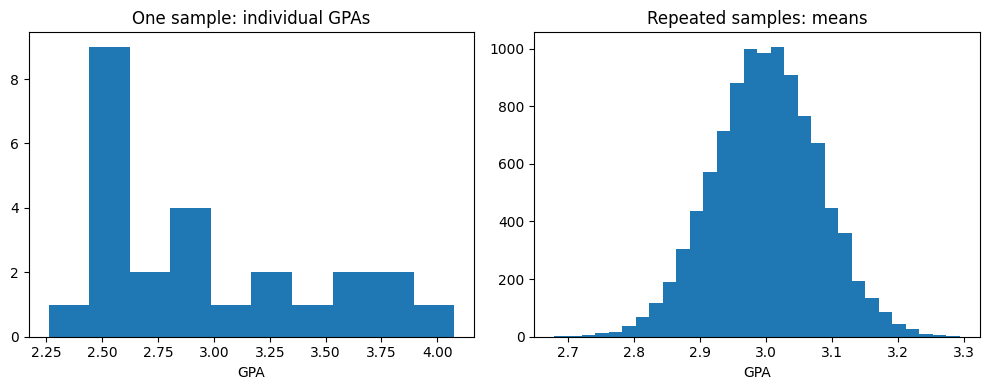

In [372]:
mu, sigma, n = 3, .4, 25
B = 10_000
one_sample = np.random.default_rng().normal(mu, sigma, size=n)
repeated = np.random.default_rng().normal(mu, sigma, size=(B, n))
sample_means = repeated.mean(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(one_sample, bins=10)
axes[0].set_title("One sample: individual GPAs")
axes[1].hist(sample_means, bins=30)
axes[1].set_title("Repeated samples: means")
for ax in axes: 
    ax.set_xlabel("GPA")
plt.tight_layout()

`Your answer here`

In [373]:
print(.4/np.sqrt(25))
print(sample_means.std(ddof=1))
print(one_sample.mean())

0.08
0.0805636681201538
2.949572794677208


Left Histogram: 25 observations with a spread of .4 and a center of 2.9. Shape of the observations is slighty right-skewed but we expect it to become normal as n increases since the population is defined as normal. 

Right Histogram: Sampling distribution of sample means with a center of 3.0 for B = 10,000 samples each with size n = 25. The shape of this distribution is normal. The theoretical standard error is calculated with sigma/sqrt(n) (.4/sqrt(25)) = .08 confirmed by the standard deviation of the empirical SD of the 10,000 samples = .08. 

## Problem 3.26.

When sample data were used to rank states by brain cancer rates, Ellenberg (2014) noted
that the highest ranking state (South Dakota) and the nearly lowest ranking state (North
Dakota) had relatively small sample sizes. Also, when schools in North Carolina were ranked
by their average improvement in test scores, the best and the worst schools were very small
schools. Explain how these results could merely reflect how the variability of sample means and
proportions depends on the sample size.

`Your answer here`

20 2.298834439831954
80 1.116036643264615
320 0.553579743260444


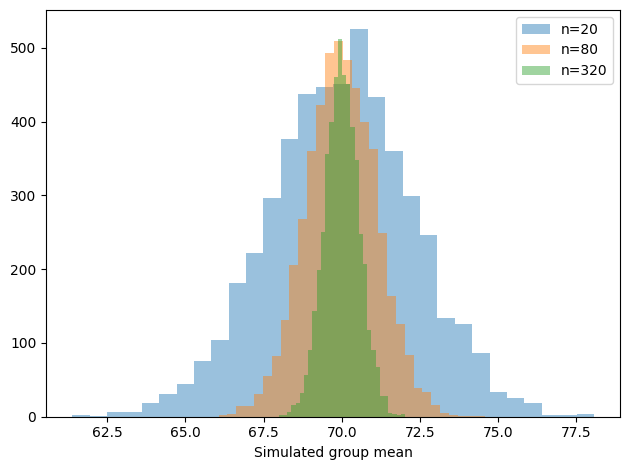

In [374]:
true_mean = 70
pop_sd = 10
demo_sizes = [20, 80, 320]
B = 5_000
for n in demo_sizes:
    means = np.random.default_rng().normal(true_mean, pop_sd, size=(B, n)).mean(axis=1)
    print(n, means.std(ddof=1))
    plt.hist(means, bins=30, alpha=.45, label=f"n={n}")
plt.xlabel("Simulated group mean")
plt.legend(); plt.tight_layout()

The standard error for a sample distribution relies on the size of the sample (sigma / sqrt(n)) where n = sample size so for as n gets smaller, the standard error gets larger therefore we get a larger spread/variance and wider sample distribution meaning our observed statistic can land further from it's true value where a larger n would give us a smaller spread leading to a tighter sample distribution around our true value. This is why the schools and states ended up on opposite extremes in this scenario.

## AI Problem: Simulating Sampling Variability in AI Metrics

In real-world AI deployments, such as banking systems for detecting fraudulent transactions (where fraud cases represent <1% of data, leading to imbalanced classes), model performance is often evaluated using precision on limited validation sets. A baseline model like logistic regression might show 0.90 precision on a small validation sample of n=100, outranking a more sophisticated ensemble method at 0.60, yet on full production data, the ensemble excels. 

Use Python to simulate the phenomenon. Assume "true" population precisions for the logistic model (mean ≈0.85, σ=0.10) and ensemble (mean ≈0.88, σ=0.08) follow a lognormal distribution to reflect the positive-skewed nature of precision scores in imbalanced settings. Generate populations of size 10,000 for each model, then perform 1,000 bootstrap resamples at n=50 (small validation) and n=500 (realistic production scale). Compute and plot the sampling distributions of the bootstrap means for both models in each scenario. Calculate the empirical SE for the small-n case. Explain how CLT predicts the distribution shapes, why extreme rankings emerge at low n, and how this variability impacts AI decisions. Propose a mitigation for imbalanced data to prevent errant decisions.

`Your answer here`

In [375]:
rng = np.random.default_rng()
def lognormal_params(mean, sd):
    log_var = np.log1p((sd/mean)**2)
    return np.log(mean)-log_var/2, np.sqrt(log_var)
def make_population(mean, sd, size=10_000):
    log_mu, log_sd = lognormal_params(mean, sd)
    return rng.lognormal(log_mu, log_sd, size)
targets = {"logistic": (.85, .1), "ensemble": (.88, .08)}
pops = {k: make_population(*v) for k, v in targets.items()}
for k, x in pops.items():
    print(k, len(x), x.mean(), x.std(ddof=1), (x>1).mean())

logistic 10000 0.8503893450051686 0.10046770437947343 0.0753
ensemble 10000 0.8803473499131808 0.0801973696950729 0.0748


In [376]:
def resampled_means(pop, n, B=1_000):
    index = rng.integers(0, len(pop), size=(B, n))
    return pop[index].mean(axis=1)
sizes = [50, 500]
results = {}
for model, pop in pops.items():
    for n in sizes:
        results[(model, n)] = resampled_means(pop, n, B=1_000)
for key, values in results.items():
    print(key, len(values), values.mean(), values.std(ddof=1))

('logistic', 50) 1000 0.850449604832567 0.013807296459589702
('logistic', 500) 1000 0.8503773646849577 0.004508397366236357
('ensemble', 50) 1000 0.8800407594232929 0.011050522108977697
('ensemble', 500) 1000 0.8801252767747674 0.003559995296770998


logistic 0.013807296459589702
ensemble 0.011050522108977697


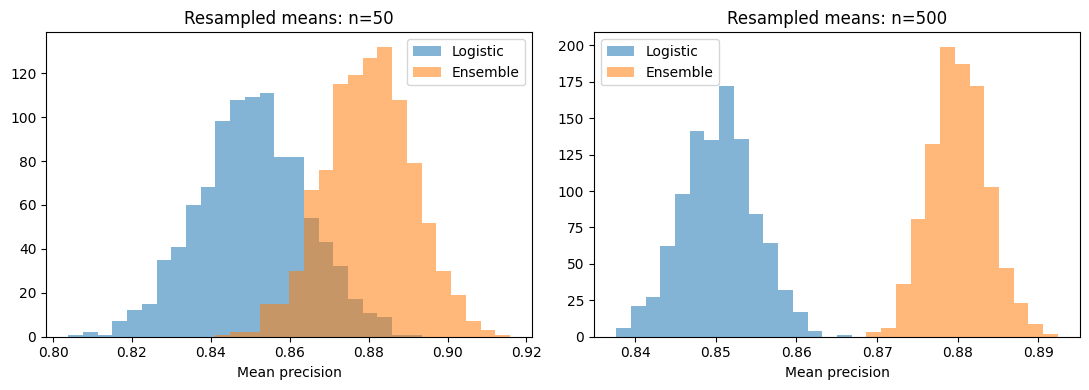

In [377]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, n in zip(axes, sizes):
    a = results[("logistic", n)]
    b = results[("ensemble", n)]
    edges = np.linspace(min(a.min(), b.min()),max(a.max(), b.max()), 31)
    ax.hist(a, bins=edges, alpha=.55, label="Logistic")
    ax.hist(b, bins=edges, alpha=.55, label="Ensemble")
    ax.set_title(f"Resampled means: n={n}")
    ax.set_xlabel("Mean precision")
    ax.legend()
plt.tight_layout()
for model in pops:
    print(model, results[(model, 50)].std(ddof=1))

Support violation: ~.08 of the logistic population and ~.07 of the ensemble population exceed a precision of 1.

Logistic Model Empirical SE: The standard error for the logistic model is .01 at n = 50.

Ensemble Model Empirical SE: The standard error for the ensemble model is .01 at n = 50.

Logistic Model Distribution at n = 50: The distribution of the logistic model at n - 50 has center and spread of (Y_bar, SE) = (.85, .01) with a bell-shaped curve. There is some overlap with the ensemble model distribution on the right tail of the logistic model distribution.

Ensemble Model Distribution at n = 50: The distribution of the ensemble model at n = 50 has center and spread of (Y_bar, SE) = (.88, .01) with a bell-shaped curve. There is some overlap with the logistic model distribution on the left tail of the ensemble model distribution.

Logistic Model Distribution at n = 500: The distribution of the logistic model at n = 500 has a center and spread of (Y_bar, SE) = (.85, .00) with a bell-shaped curve. There is no meaningful overlap.

Ensemble Model Distribution at n = 500: The distribution of the ensemble model at n = 500 has a center and spread of (Y_bar, SE) = (.88, .00) with a bell-shaped curve. There is no meaningful overlap.

CLT is justified here when n = 500 and n = 50 since both are large samples, so we can see the distribution is approximately normal. The overlap disappears from n = 50 to n = 500 since a large sample produces less spread.


** AI Disclaimer **

I used Claude in this assignment to clarify the questions and verify my answers to check if I've answered correctly, fully, and to help with wording of interpretations.